In [1]:
# Month 2 Week 1 — Backtesting a Trading Strategy

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 5 years of data
spy = yf.download("SPY", period="5y")["Close"].squeeze()

# Moving averages and signal
ma50  = spy.rolling(50).mean()
ma200 = spy.rolling(200).mean()

signal = (ma50 > ma200).astype(int)

# Shift signal by 1 day — CRITICAL to avoid lookahead bias
# You can only act on yesterday's signal, not today's
signal_shifted = signal.shift(1)

print("Signal value counts:")
print(signal_shifted.value_counts())

[*********************100%***********************]  1 of 1 completed

Signal value counts:
SPY
1.0    789
0.0    465
Name: count, dtype: int64


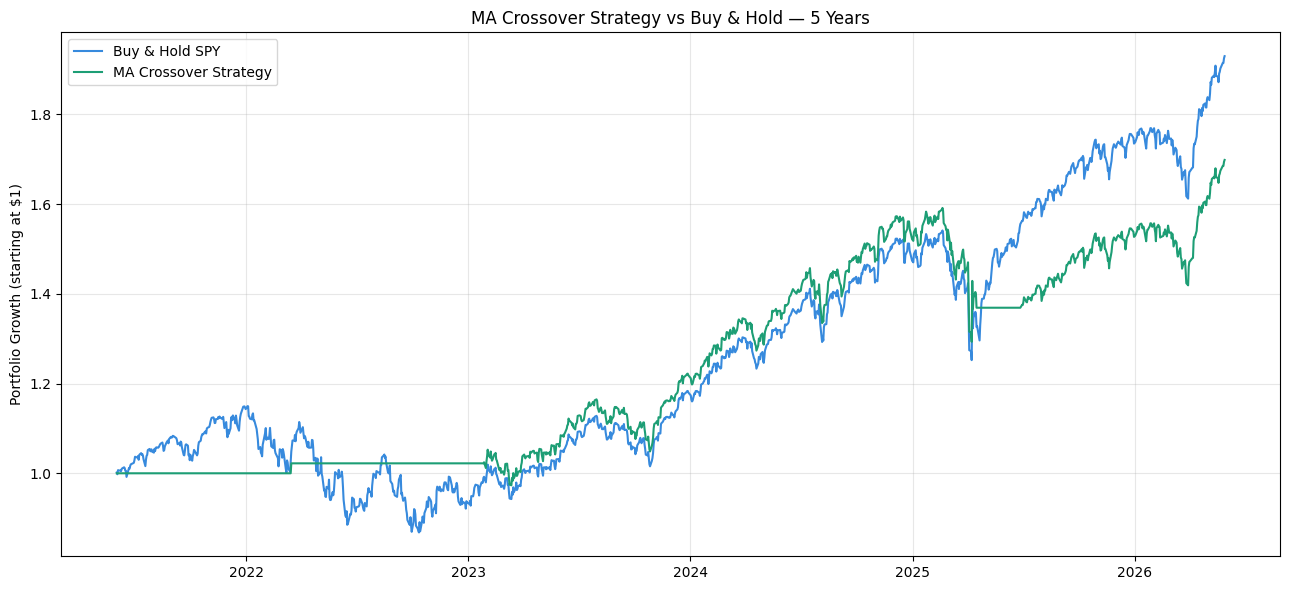

In [3]:
#Compute strategy returns and equity curve
#Apply the signal to daily returns — when signal is 1 you earn SPY's return, when 0 you earn nothing (sitting in cash):
# Daily returns
daily_returns = spy.pct_change().dropna()

# Align signal with returns,forces the signal to have exactly the same dates as the returns.
signal_aligned = signal_shifted.reindex(daily_returns.index).fillna(0)

# Strategy returns: only earn market return when signal = 1
#switching between "in market" and "in cash" by multiplying by 1 or 0.
strategy_returns = daily_returns * signal_aligned

# Cumulative equity curves
#This compounds the returns into a growth curve starting from $1.
equity_strategy  = (1 + strategy_returns).cumprod()
equity_buyhold   = (1 + daily_returns).cumprod()

# Plot
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(equity_buyhold.index,  equity_buyhold.values,
        color="#378ADD", linewidth=1.5, label="Buy & Hold SPY")
ax.plot(equity_strategy.index, equity_strategy.values,
        color="#1D9E75", linewidth=1.5, label="MA Crossover Strategy")
ax.set_title("MA Crossover Strategy vs Buy & Hold — 5 Years")
ax.set_ylabel("Portfolio Growth (starting at $1)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
#ℹ cumprod() compounds returns — (1+r1) × (1+r2) × ... gives you total growth from $1. If the final value is 1.45, your $1 became $1.45 — a 45% total return.

In [4]:
def performance_report(returns, name):
    total   = (1 + returns).cumprod().iloc[-1] - 1 #compounds all daily returns into a growth curve starting at $1, takes last val, coverts growth to return
    ann_ret = returns.mean() * 252
    ann_vol = returns.std() * np.sqrt(252) #Daily volatility scaled to annual using square root of time
    sharpe  = (ann_ret - 0.045) / ann_vol # annualised excess return divided by annualised volatility.
    drawdown= ((1+returns).cumprod() / (1+returns).cumprod().cummax() - 1).min()

    print(f"--- {name} ---")
    print(f"Total Return:      {total*100:.2f}%")
    print(f"Ann. Return:       {ann_ret*100:.2f}%")
    print(f"Ann. Volatility:   {ann_vol*100:.2f}%")
    print(f"Sharpe Ratio:      {sharpe:.2f}")
    print(f"Max Drawdown:      {drawdown*100:.2f}%")
    print()

performance_report(strategy_returns.dropna(), "MA Crossover")
performance_report(daily_returns, "Buy & Hold SPY")

#The pattern to notice: the strategy likely has lower volatility AND lower return than buy-and-hold. 
#it avoided some crashes but also missed big rallies. 
#Whether the vol reduction is worth the return sacrifice depends on the investor.

--- MA Crossover ---
Total Return:      69.86%
Ann. Return:       11.36%
Ann. Volatility:   11.95%
Sharpe Ratio:      0.57
Max Drawdown:      -18.76%

--- Buy & Hold SPY ---
Total Return:      93.00%
Ann. Return:       14.67%
Ann. Volatility:   17.06%
Sharpe Ratio:      0.60
Max Drawdown:      -24.50%



In [5]:
#Every buy and sell incurs a cost. Count your trades to understand how much friction the strategy has:
# Count number of trades (signal changes)
trades = signal_shifted.diff().abs().sum()
print(f"Total trades over 5 years: {int(trades)}")
print(f"Avg trades per year: {trades/5:.1f}")

# Rough transaction cost estimate
# Assume 0.05% per trade (realistic for retail)
cost_per_trade = 0.0005
total_cost = trades * cost_per_trade
print(f"Estimated total transaction cost: {total_cost*100:.2f}%")
print(f"Drag on annual return: {(total_cost/5)*100:.2f}% per year")
#ℹ MA crossover strategies typically trade infrequently — maybe 4-8 times per year. That's actually low friction. 
#High-frequency strategies that trade hundreds of times per day can see transaction costs completely wipe out theoretical returns.

Total trades over 5 years: 5
Avg trades per year: 1.0
Estimated total transaction cost: 0.25%
Drag on annual return: 0.05% per year


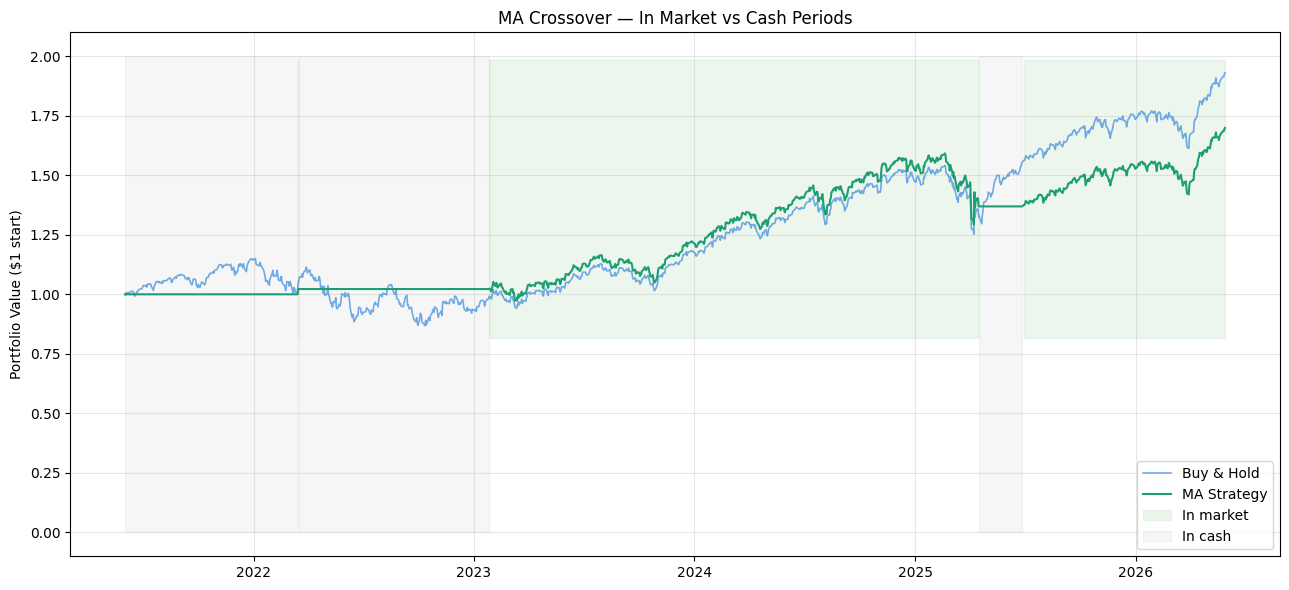

In [6]:
#Plot the signal regions on the equity curve
#Shade the chart to show when the strategy was in (holding SPY) vs out (holding cash):
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(equity_buyhold.index, equity_buyhold.values,
        color="#378ADD", linewidth=1.2, label="Buy & Hold", alpha=0.7)
ax.plot(equity_strategy.index, equity_strategy.values,
        color="#1D9E75", linewidth=1.5, label="MA Strategy")

# Shade: in market (green) vs cash (grey)
ax.fill_between(signal_aligned.index,
    ax.get_ylim()[0], ax.get_ylim()[1] if ax.get_ylim()[1]>0 else 2,
    where=(signal_aligned==1), alpha=0.07, color="green", label="In market")
ax.fill_between(signal_aligned.index,
    0, 2,
    where=(signal_aligned==0), alpha=0.07, color="grey", label="In cash")

ax.set_title("MA Crossover — In Market vs Cash Periods")
ax.set_ylabel("Portfolio Value ($1 start)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

"The grey periods show the strategy successfully avoided the 2022 bear market entirely by sitting in cash, which is its core value — but the lag in signal detection meant it missed the early 2023 recovery, ultimately underperforming buy-and-hold by about 23 percentage points over 5 years while delivering a meaningfully smoother equity curve."

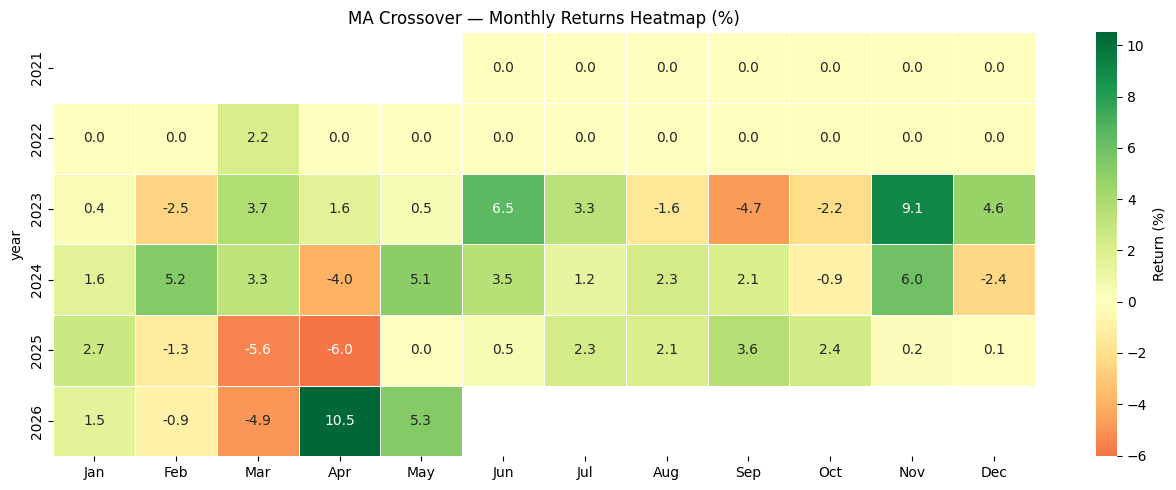

In [7]:
#Plot monthly returns heatmap, shows which months and years the strategy performed well:
# Reshape returns into monthly buckets
monthly = strategy_returns.resample("ME").apply( #groups daily returns by month-end
    lambda x: (1+x).prod() - 1 #compounds the daily returns within each month 
) * 100

# Pivot into year x month grid
monthly_df = monthly.to_frame("return")
monthly_df["year"]  = monthly_df.index.year
monthly_df["month"] = monthly_df.index.month
pivot = monthly_df.pivot(index="year", columns="month", values="return")
pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                 "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(13, 5))
import seaborn as sns
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn",
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={"label":"Return (%)"})
ax.set_title("MA Crossover — Monthly Returns Heatmap (%)")
plt.tight_layout()
plt.show()


## Strategy Assessment — MA Crossover on SPY

### What the strategy does
This strategy buys SPY (the S&P 500 ETF) when the 50-day moving average crosses above the 200-day moving average (the "golden cross"), 
and sells to cash when the 50-day crosses back below the 200-day (the "death cross").

### Performance vs benchmark
--- MA Crossover ---
Total Return:      69.86%
Sharpe Ratio:      0.57
Max Drawdown:      -18.76%

--- Buy & Hold SPY ---
Total Return:      93.00%
Sharpe Ratio:      0.60
Max Drawdown:      -24.50%

The strategy underperforms on every return metric but delivers meaningfully lower drawdown — 
you're giving up ~23% of gains to cut peak losses by ~5.7 percentage points.
### Where it adds value
Drawdown protection — max drawdown of −18.76% vs −24.50% for buy & hold, a ~24% reduction in peak loss.
Avoided the 2022 crash — the death cross triggered early in 2022, keeping the strategy in cash during the worst of the Fed tightening selloff (visible as the flat 0.0s in the heatmap).
Psychological comfort — smaller drawdowns make it easier to stay the course without panic-selling

### Where it falls short
Lags entries and exits — MAs are inherently lagging indicators; by the time a crossover fires, a significant portion of the move has already happened
Misses rallies while in cash — the 2021 bull run and the 2023–2024 recovery gains were partially missed during cash periods.
Whipsaws in sideways markets — March–April 2025 (−5.6%, −6.0%) is a textbook example: the MA crossover flipped signals repeatedly in a choppy market, generating losses on both sides.
Lower Sharpe despite lower risk — the risk-adjusted return is still worse than simply holding, meaning the volatility reduction doesn't fully compensate for the return sacrifice.

### What I would improve
Add a second confirmation signal — require RSI > 50 or positive MACD before entering, to filter out false golden crosses in low-momentum environments
Volume filter — only act on crossovers accompanied by above-average volume, which tends to confirm genuine trend changes.
Reduce whipsaw with a buffer zone — require the 50-day to exceed the 200-day by a minimum threshold (e.g. 1–2%) before triggering, avoiding signals on near-flat crossings.
Optimise MA window lengths — 50/200 is the classic pair but 20/100 or adaptive MAs may suit SPY's volatility profile better; walk-forward optimisation would test this properly.
Test on multiple assets — trend-following works better on assets with persistent momentum (commodities, bonds, international indices); benchmarking across these would reveal whether the edge is strategy-specific or SPY-specific.
Partial position sizing — instead of 100% in / 100% out, scale exposure based on signal strength or volatility (e.g. VIX level) to smooth the transition and reduce whipsaw losses.